# 02 · Bivariate relationships and nonlinear dependence

Compare linear, rank-based, partial and general dependence. Raw grouped scatters are shown beside Ruddy correlation, distance-correlation and mutual-information results.

In [10]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_bivariate, analyze_dependence, analyze_contingency_diagnostics
frame, dataset = load_tabular_demo()
biv = analyze_bivariate(dataset)
dep = analyze_dependence(dataset, partial_covariates=('length',), n_permutations=19, random_state=42)
cont = analyze_contingency_diagnostics(dataset, pairs=(('group','phenotype'),))

## Strong grouped scatter: linear association

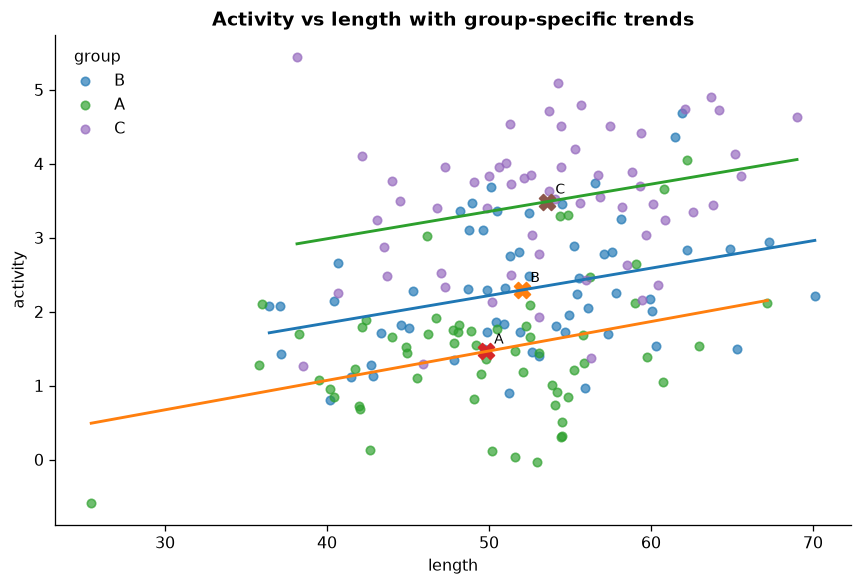

In [11]:
scatter_by_group(frame, x='length', y='activity', group='group', title='Activity vs length with group-specific trends'); plt.show()

## Nonlinear relationship missed by linear correlation

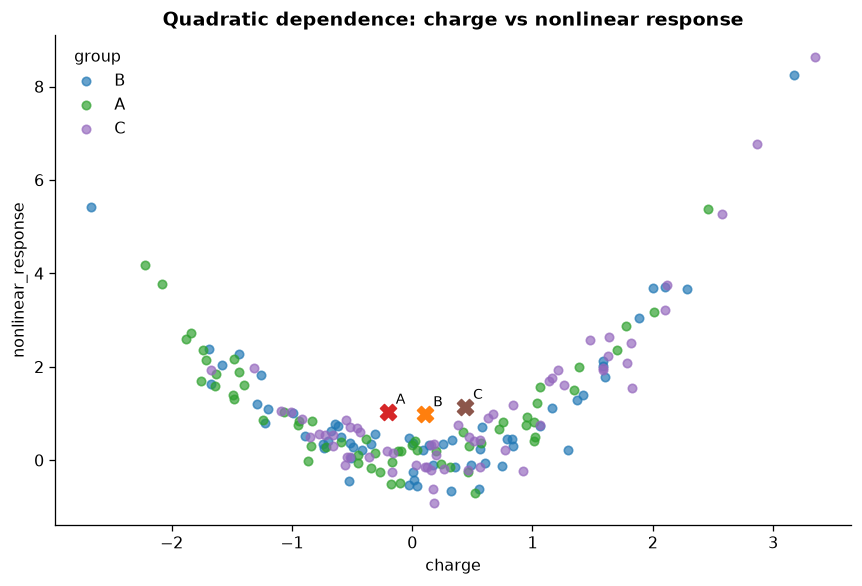

In [12]:
scatter_by_group(frame, x='charge', y='nonlinear_response', group='group', title='Quadratic dependence: charge vs nonlinear response', fit_lines=False); plt.show()

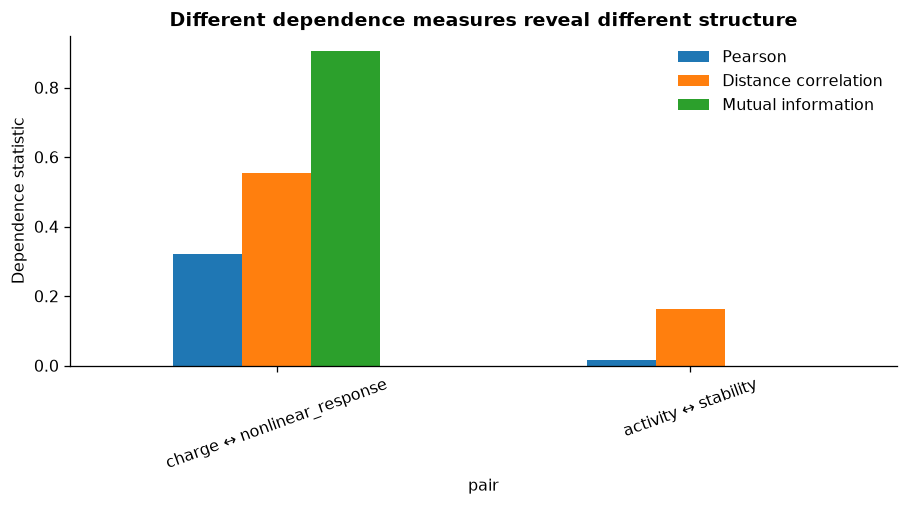

,Pearson,Distance correlation,Mutual information
pair,,,
charge ↔ nonlinear_response,0.320785,0.554659,0.904425
activity ↔ stability,0.017236,0.162781,0.000000


In [13]:
pairs = [('charge','nonlinear_response'),('length','activity'),('activity','stability')]
rows=[]
for x,y in pairs:
    p=biv.correlations.query('column_x==@x and column_y==@y and method=="pearson"')
    d=dep.distance_correlations.query('column_x==@x and column_y==@y')
    m=dep.mutual_information.query('column_x==@x and column_y==@y')
    if len(p) and len(d) and len(m): rows.append({'pair':f'{x} ↔ {y}','Pearson':p.iloc[0].coefficient,'Distance correlation':d.iloc[0].statistic,'Mutual information':m.iloc[0].statistic})
compare=pd.DataFrame(rows).set_index('pair')
fig,ax=plt.subplots(figsize=(8,4.5)); compare.plot(kind='bar',ax=ax); ax.set_ylabel('Dependence statistic'); ax.set_title('Different dependence measures reveal different structure'); ax.tick_params(axis='x',rotation=20); finish(fig); plt.show()
display(compare)

## Global dependence matrices

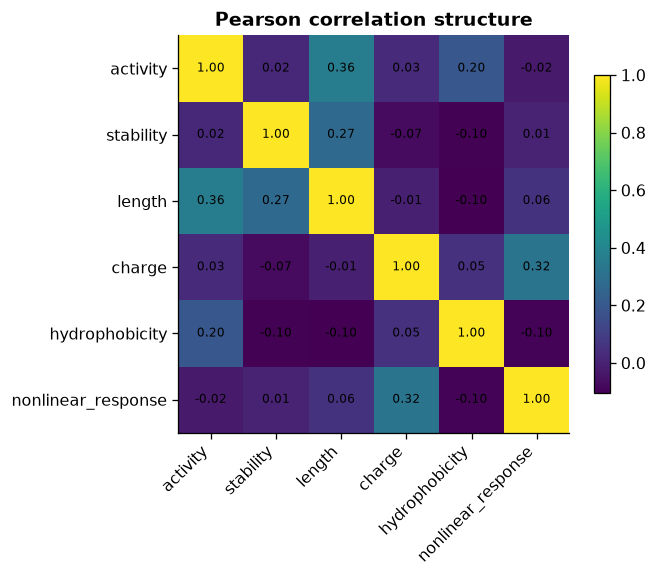

In [14]:
numeric=['activity','stability','length','charge','hydrophobicity','nonlinear_response']
pear=biv.correlations.query('method=="pearson" and status=="ok"')
pm=pd.DataFrame(np.eye(len(numeric)),index=numeric,columns=numeric)
for _,r in pear.iterrows():
    if r.column_x in numeric and r.column_y in numeric: pm.loc[r.column_x,r.column_y]=pm.loc[r.column_y,r.column_x]=r.coefficient
matrix_heatmap(pm,title='Pearson correlation structure'); plt.show()

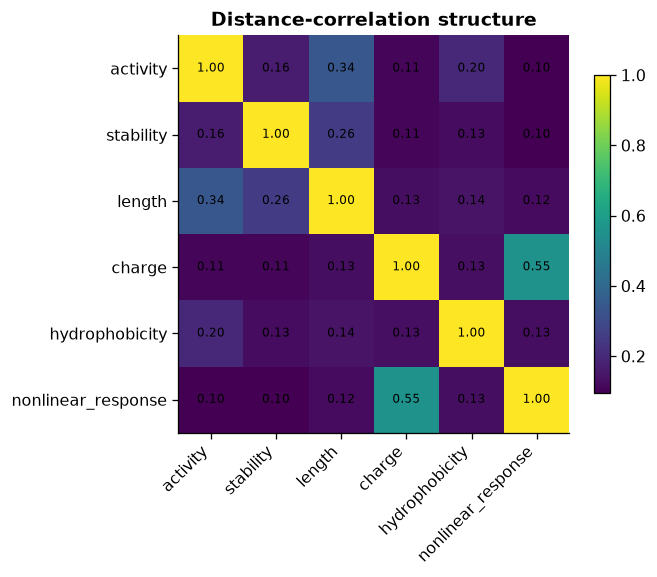

In [15]:
dc=dep.distance_correlations.query('status=="ok"')
dm=pd.DataFrame(np.eye(len(numeric)),index=numeric,columns=numeric)
for _,r in dc.iterrows():
    if r.column_x in numeric and r.column_y in numeric: dm.loc[r.column_x,r.column_y]=dm.loc[r.column_y,r.column_x]=r.statistic
matrix_heatmap(dm,title='Distance-correlation structure'); plt.show()

## Partial correlation: controlling for length

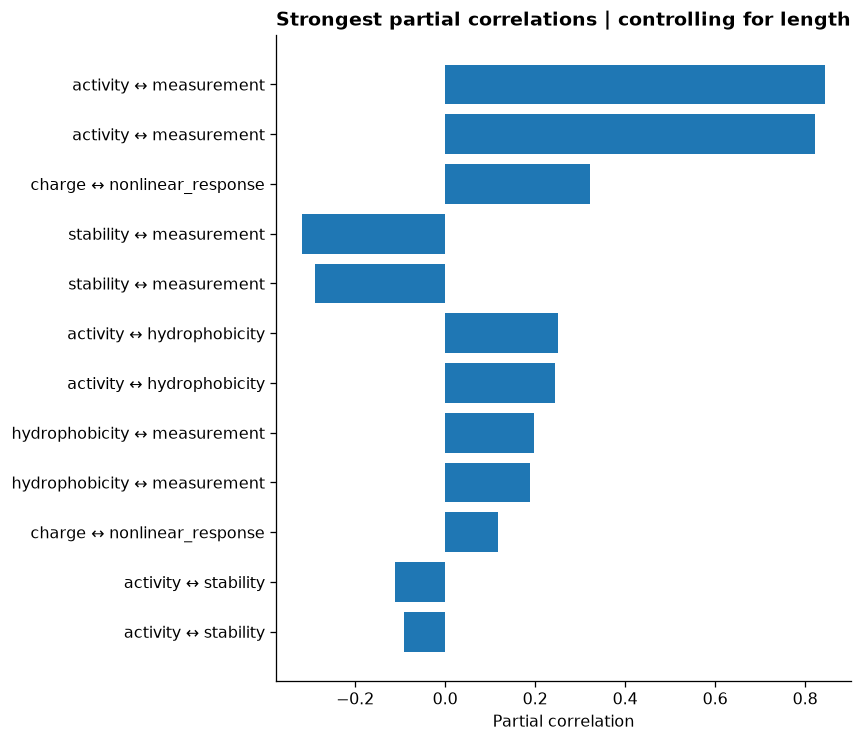

In [16]:
pc=dep.partial_correlations.query('status=="ok"').copy(); pc['pair']=pc.column_x+' ↔ '+pc.column_y
top=pc.reindex(pc.coefficient.abs().sort_values(ascending=False).index).head(12)
bar_metric(top,label='pair',value='coefficient',title='Strongest partial correlations | controlling for length',ylabel='Partial correlation'); plt.show()

## Categorical association: which cells drive the result?

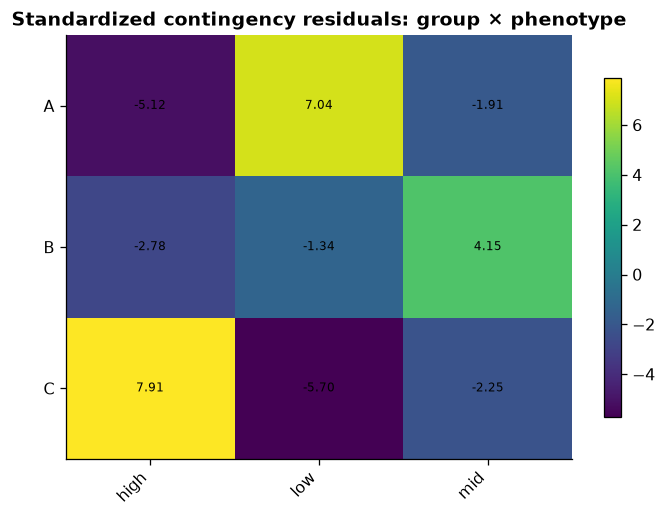

,column_x,column_y,n_total,n_used,n_x_levels,n_y_levels,chi_square,df,p_value,q_value,family_id,family_size,correction,cramers_v,min_expected_count,n_expected_lt5,fraction_expected_lt5,status,reason
0,group,phenotype,180,180,3,3,91.451709,4.0,6.472484e-19,6.472484e-19,contingency:chi_square,1,fdr_bh,0.495584,19.666667,0,0.0,ok,None


In [17]:
cells=cont.cells.query('column_x=="group" and column_y=="phenotype"')
res=cells.pivot(index='level_x',columns='level_y',values='standardized_residual')
matrix_heatmap(res,title='Standardized contingency residuals: group × phenotype'); plt.show()
display(cont.summary)

## Interactive grouped scatter

In [18]:
import plotly.express as px
fig = px.scatter(frame.replace([np.inf,-np.inf],np.nan), x='charge', y='nonlinear_response', color='group', hover_data=['id','source','activity'], title='Interactive nonlinear dependence explorer')
fig